# Part 1 — Data Preprocessing and Preparation

In this notebook, I performed the complete preprocessing pipeline for the gait dataset.  
The main objectives of this stage were:

1. To combine raw Accelerometer and Gyroscope data into a single 6-channel signal.  
2. To segment each user’s continuous signal into overlapping 5-second windows.  
3. To analyze the raw signals for noise and outliers.  
4. To clean the signals using Z-score–based outlier clipping and Moving Average smoothing.  
5. To save the processed windowed data for later FNN and LSTM model training.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.stats import zscore
from tqdm import tqdm

# Base paths (reflecting my current folder structure)
DATA_DIR = "../sample_data"
OUTPUT_DIR = "../processed_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Global parameters
USERS = [2, 13, 23, 24, 49, 52, 55, 70, 78, 112]
SAMPLING_RATE = 50                # 50 Hz → 50 samples/sec
WINDOW_SIZE_SEC = 5
WINDOW_SIZE = WINDOW_SIZE_SEC * SAMPLING_RATE
OVERLAP = 0.5
STEP_SIZE = int(WINDOW_SIZE * (1 - OVERLAP))



## 1. Data Consolidation

Each user has two CSV files — one Accelerometer and one Gyroscope file.  
I combined them into a single 6-channel time-series dataset with the structure:  
**[Acc-X, Acc-Y, Acc-Z, Gyro-X, Gyro-Y, Gyro-Z]**.  
Both signals were aligned by timestamp using nearest-neighbor interpolation to ensure temporal synchronization.


   Time     Acc_X      Acc_Y     Acc_Z    Gyro_X    Gyro_Y    Gyro_Z
0     0  1.978808  -1.114501  3.514688  0.579504 -0.647681  0.233293
1     1  0.810437  -2.832341  2.801216  1.075917 -1.181378  0.243946
2     2 -0.252588  -5.337873  2.322376  1.538242 -1.643703  0.274838
3     3 -1.994370  -8.580819  0.926556  1.940912 -1.842908  0.297209
4     4 -3.323152 -11.498154 -0.196325  2.179531 -1.902562  0.373908


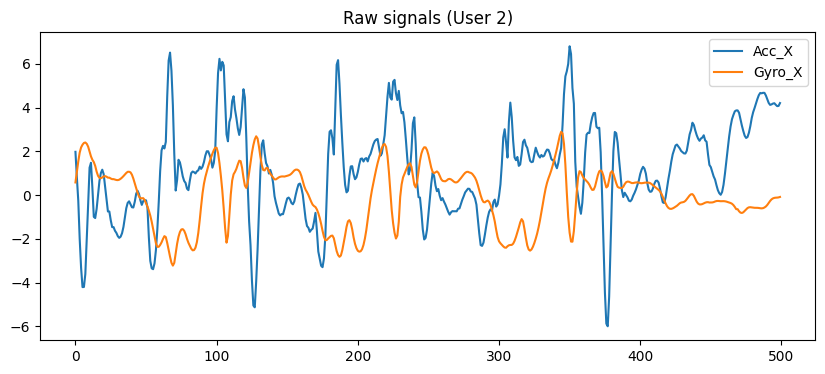

In [2]:
def load_sensor_data(user_id: int):
    """Load accelerometer and gyroscope CSVs for a user and return merged DataFrame."""
    acc_path  = os.path.join(DATA_DIR, f"{user_id}_PocketPhone_Accelerometer_(Samsung_S6).csv")
    gyro_path = os.path.join(DATA_DIR, f"{user_id}_PocketPhone_Gyroscope_(Samsung_S6).csv")

    acc = pd.read_csv(acc_path)
    gyro = pd.read_csv(gyro_path)

    # Keep only time + XYZ columns (robust to extra columns)
    acc = acc.iloc[:, :4]; gyro = gyro.iloc[:, :4]
    acc.columns  = ["Time", "Acc_X", "Acc_Y", "Acc_Z"]
    gyro.columns = ["Time", "Gyro_X", "Gyro_Y", "Gyro_Z"]

    # Align by timestamp (interpolate if needed)
    merged = pd.merge_asof(
        acc.sort_values("Time"), gyro.sort_values("Time"),
        on="Time", direction="nearest"
    )

    merged.dropna(inplace=True)
    return merged

# Example visual check
sample_user = 2
data = load_sensor_data(sample_user)
print(data.head())

plt.figure(figsize=(10,4))
plt.plot(data["Acc_X"][:500], label="Acc_X")
plt.plot(data["Gyro_X"][:500], label="Gyro_X")
plt.title(f"Raw signals (User {sample_user})")
plt.legend()
plt.show()


## 1.1 Raw Data Analysis

Before applying any cleaning, I visualized a few users’ raw signals to understand the level of noise.  
The plots below show that the signals contain irregular spikes and small-amplitude jitter — evidence of sensor noise and motion artifacts.


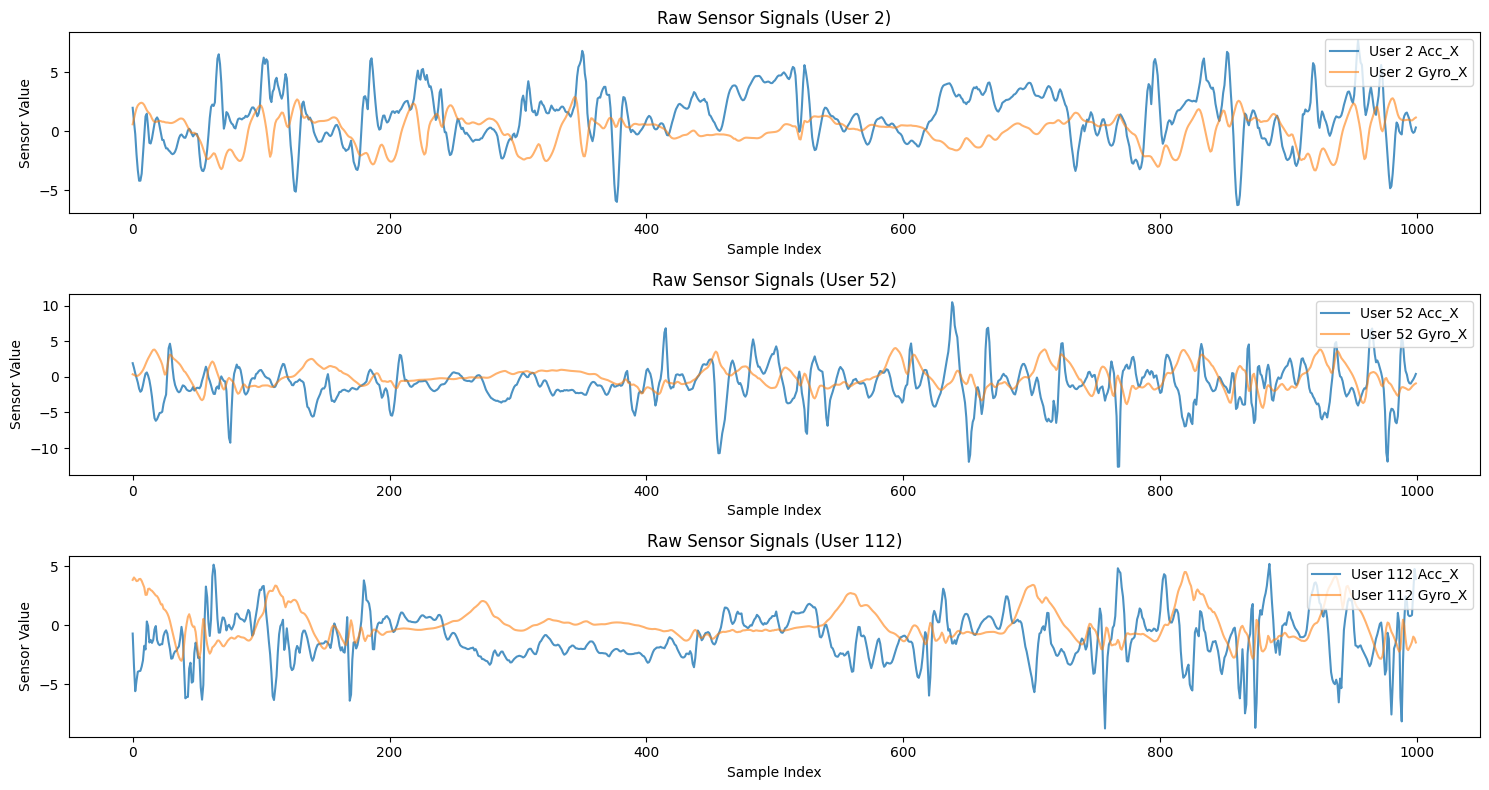

In [4]:
users_to_plot = [2, 52, 112]

plt.figure(figsize=(15, 8))
for i, uid in enumerate(users_to_plot, 1):
    df = load_sensor_data(uid)
    plt.subplot(3, 1, i)
    plt.plot(df["Acc_X"][:1000], label=f"User {uid} Acc_X", alpha=0.8)
    plt.plot(df["Gyro_X"][:1000], label=f"User {uid} Gyro_X", alpha=0.6)
    plt.title(f"Raw Sensor Signals (User {uid})")
    plt.xlabel("Sample Index")
    plt.ylabel("Sensor Value")
    plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


## 2. Sliding Window Segmentation

I segmented each user’s continuous signal into 5-second windows with 50 % overlap.  
Each window corresponds to one sample that will later be used as input to the neural networks.  
At a sampling rate of 50 Hz, each window contains 250 time steps and each sample has 6 features.


In [5]:
def create_windows(df: pd.DataFrame, window_size: int, step_size: int):
    """Convert time-series into overlapping windows."""
    windows = []
    for start in range(0, len(df) - window_size + 1, step_size):
        segment = df.iloc[start:start + window_size, 1:].values  # skip Time col
        windows.append(segment)
    return np.array(windows)

# Example
windows = create_windows(data, WINDOW_SIZE, STEP_SIZE)
print("Windows shape:", windows.shape)


Windows shape: (279, 250, 6)


## 3. Outlier Detection and Noise Cleaning

From the analysis, I observed that some samples contain extreme spikes and random noise.  
To address this, I applied two cleaning techniques:

1. **Z-score–based outlier detection** — limits values that deviate more than ±3 σ from the mean.  
2. **Moving Average smoothing** — reduces high-frequency noise while retaining gait patterns.


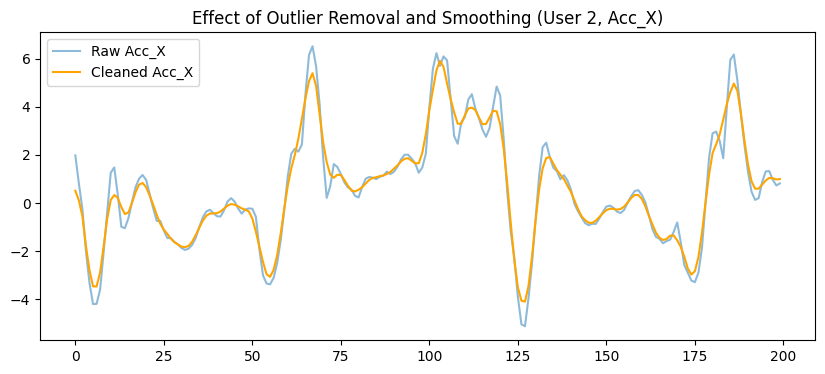

In [6]:
def remove_outliers_zscore(window, threshold=3.0):
    """Clamp extreme values beyond Z-score threshold."""
    z = zscore(window, axis=0)
    window[np.abs(z) > threshold] = np.sign(window[np.abs(z) > threshold]) * threshold
    return window

def smooth_signal(window, kernel=5):
    """Apply moving average smoothing."""
    return np.apply_along_axis(lambda x: np.convolve(x, np.ones(kernel)/kernel, mode='same'), 0, window)

# Example visualization
raw = windows[0]
clean = smooth_signal(remove_outliers_zscore(raw))

plt.figure(figsize=(10,4))
plt.plot(raw[:200,0], alpha=0.5, label="Raw Acc_X")
plt.plot(clean[:200,0], label="Cleaned Acc_X", color='orange')
plt.title("Effect of Outlier Removal and Smoothing (User 2, Acc_X)")
plt.legend()
plt.show()


### 3.1 Outlier Detection Visualization

I analyzed one 5-second window to visualize detected outliers using the Z-score method.  
Values exceeding ±3 standard deviations are highlighted in red.


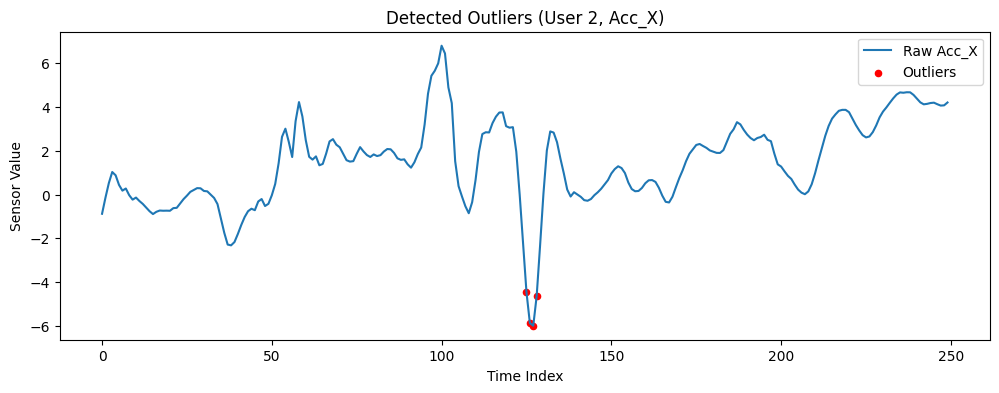

Outliers detected: 4 / 250 (1.60%)


In [15]:
from scipy.stats import zscore

signal = windows[2][:, 0]  # Acc_X
z = zscore(signal)
outliers = np.where(np.abs(z) > 3)[0]

plt.figure(figsize=(12,4))
plt.plot(signal, label="Raw Acc_X")
plt.scatter(outliers, signal[outliers], color='red', label='Outliers', s=20)
plt.title("Detected Outliers (User 2, Acc_X)")
plt.xlabel("Time Index")
plt.ylabel("Sensor Value")
plt.legend()
plt.show()

print(f"Outliers detected: {len(outliers)} / {len(signal)} ({len(outliers)/len(signal)*100:.2f}%)")


## 4. Applying Preprocessing to All Users

After verifying that the cleaning works effectively, I applied the full pipeline —  
merging, windowing, outlier clipping, and smoothing — to all 10 users and saved the processed data as NumPy arrays for later experiments.


In [16]:
all_data = {}

for uid in tqdm(USERS, desc="Processing Users"):
    df = load_sensor_data(uid)
    w = create_windows(df, WINDOW_SIZE, STEP_SIZE)

    cleaned = np.array([
        smooth_signal(remove_outliers_zscore(win))
        for win in w
    ])

    all_data[uid] = cleaned
    np.save(os.path.join(OUTPUT_DIR, f"user_{uid}_windows.npy"), cleaned)

print("✅ Saved processed windows for all users.")


Processing Users: 100%|██████████| 10/10 [00:01<00:00,  5.64it/s]

✅ Saved processed windows for all users.
